In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Check GPU
import torch
print("\n" + "="*70)
print("🖥️  SYSTEM CHECK")
print("="*70)
print(f"GPU Available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    print("\n✅ GPU is ready! Training will be FAST!")
else:
    print("\n⚠️  WARNING: No GPU detected!")
    print("Go to: Runtime → Change runtime type → GPU")
    print("Then restart this notebook")

print("="*70)

Mounted at /content/drive

🖥️  SYSTEM CHECK
GPU Available: True
GPU Name: Tesla T4
GPU Memory: 15.83 GB

✅ GPU is ready! Training will be FAST!


In [ ]:
# Install YOLOv8
!pip install ultralytics -q

# Verify installation
from ultralytics import YOLO
import os

print("✅ Ultralytics YOLOv8 installed successfully!")
print(f"Version: {YOLO.__version__ if hasattr(YOLO, '__version__') else 'Latest'}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 26.2 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ Ultralytics YOLOv8 installed successfully!
Version: Latest


In [ ]:
from pathlib import Path

# Base directory
BASE_DIR = Path('/content/drive/MyDrive/CamouflageDetection')

# Dataset paths
DATA_YAML = BASE_DIR / '02_dataset/data.yaml'

# Output paths
MODELS_DIR = BASE_DIR / '03_models'
RESULTS_DIR = BASE_DIR / '04_results'

# Create directories
MODELS_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

# Verify dataset exists
print("📂 Checking dataset...")
print(f"Config file exists: {DATA_YAML.exists()}")

if DATA_YAML.exists():
    print(f"✅ Found: {DATA_YAML}")

    # Show config contents
    import yaml
    with open(DATA_YAML, 'r') as f:
        config = yaml.safe_load(f)

    print("\n📄 Dataset Configuration:")
    for key, value in config.items():
        print(f"  {key}: {value}")
else:
    print("❌ data.yaml not found! Run Notebook 01 first.")

📂 Checking dataset...
Config file exists: True
✅ Found: /content/drive/MyDrive/CamouflageDetection/02_dataset/data.yaml

📄 Dataset Configuration:
  names: ['camouflaged_person']
  nc: 1
  path: /content/drive/MyDrive/CamouflageDetection/02_dataset
  test: test/images
  train: train/images
  val: test/images


In [ ]:
print("="*70)
print("🚀 TRAINING IMPROVED MODEL - YOLOv8 MEDIUM")
print("="*70)
print("Target: 90% accuracy")
print("This will take 60-90 minutes")
print("="*70 + "\n")

from ultralytics import YOLO

# Load MEDIUM pre-trained model (bigger = better accuracy)
model = YOLO('yolov8m.pt')

# Train with augmentation
results = model.train(
    data=str(DATA_YAML),
    epochs=150,
    imgsz=640,
    batch=8,
    device=0,
    project=str(MODELS_DIR),
    name='yolo_medium_improved',
    patience=25,
    save=True,
    plots=True,
    val=True,
    verbose=True,

    # Augmentation for better accuracy
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    degrees=10,
    translate=0.1,
    scale=0.5,
    fliplr=0.5,
    mosaic=1.0,
    mixup=0.1,

    lr0=0.01,
    lrf=0.001,
    warmup_epochs=5,
    cos_lr=True,
)

print("\n✅ TRAINING COMPLETE!")

# Evaluate
print("\n📊 Evaluating new model...")
best_model = YOLO(MODELS_DIR / 'yolo_medium_improved/weights/best.pt')
metrics = best_model.val()

print("\n" + "="*70)
print("🎯 RESULTS COMPARISON")
print("="*70)
print(f"  OLD MODEL (Nano):     68.5% mAP")
print(f"  NEW MODEL (Medium):   {metrics.box.map50*100:.1f}% mAP")
print(f"  Improvement:          +{(metrics.box.map50 - 0.685)*100:.1f}%")
print("="*70)

🚀 TRAINING IMPROVED MODEL - YOLOv8 MEDIUM
Target: 90% accuracy
This will take 60-90 minutes

Ultralytics 8.4.0 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/drive/MyDrive/CamouflageDetection/02_dataset/data.yaml, degrees=10, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.001, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo_me

In [ ]:
from ultralytics import YOLO

print("="*70)
print("📦 Loading Pre-trained YOLOv8 Model")
print("="*70)

# Load YOLOv8 nano model (fastest, good for starting)
# Options: yolov8n.pt (nano), yolov8s.pt (small), yolov8m.pt (medium)
model = YOLO('yolov8n.pt')

print("\n✅ Model loaded successfully!")
print("\nModel Details:")
print(f"  Architecture: YOLOv8 Nano")
print(f"  Parameters: ~3.2M")
print(f"  Speed: Fast (real-time capable)")
print(f"  Accuracy: Good for starting")

print("\n💡 TIP: After first training, you can try yolov8s.pt for better accuracy")
print("="*70)

📦 Loading Pre-trained YOLOv8 Model

✅ Model loaded successfully!

Model Details:
  Architecture: YOLOv8 Nano
  Parameters: ~3.2M
  Speed: Fast (real-time capable)
  Accuracy: Good for starting

💡 TIP: After first training, you can try yolov8s.pt for better accuracy


In [ ]:
# Training configuration
TRAINING_CONFIG = {
    'data': str(DATA_YAML),           # Path to data.yaml
    'epochs': 100,                     # Number of training epochs
    'imgsz': 640,                      # Image size (640x640)
    'batch': 16,                       # Batch size (adjust if GPU memory error)
    'device': 0,                       # Use GPU (device 0)
    'project': str(MODELS_DIR),        # Where to save results
    'name': 'yolo_camouflage_v1',      # Experiment name
    'patience': 20,                    # Early stopping patience
    'save': True,                      # Save checkpoints
    'plots': True,                     # Generate training plots
    'val': True,                       # Validate during training
    'verbose': True,                   # Show detailed output
    'pretrained': True,                # Use pretrained weights
    'optimizer': 'auto',               # Auto-select optimizer
    'lr0': 0.01,                       # Initial learning rate
    'warmup_epochs': 3,                # Warmup epochs
    'cos_lr': True,                    # Use cosine learning rate schedule
}

print("="*70)
print("⚙️  TRAINING CONFIGURATION")
print("="*70)
for key, value in TRAINING_CONFIG.items():
    print(f"  {key}: {value}")
print("="*70)

print("\n💡 NOTES:")
print("  - Training will take 30-60 minutes")
print("  - You'll see live progress")
print("  - Model auto-saves best weights")
print("  - Can stop anytime (best model is saved)")

⚙️  TRAINING CONFIGURATION
  data: /content/drive/MyDrive/CamouflageDetection/02_dataset/data.yaml
  epochs: 100
  imgsz: 640
  batch: 16
  device: 0
  project: /content/drive/MyDrive/CamouflageDetection/03_models
  name: yolo_camouflage_v1
  patience: 20
  save: True
  plots: True
  val: True
  verbose: True
  pretrained: True
  optimizer: auto
  lr0: 0.01
  warmup_epochs: 3
  cos_lr: True

💡 NOTES:
  - Training will take 30-60 minutes
  - You'll see live progress
  - Model auto-saves best weights
  - Can stop anytime (best model is saved)


In [ ]:
print("\n" + "="*70)
print("🚀 STARTING YOLO TRAINING")
print("="*70)
print("Training on 748 images...")
print("This will take 30-60 minutes. Grab a coffee! ☕")
print("="*70 + "\n")

# Train the model
results = model.train(**TRAINING_CONFIG)

print("\n" + "="*70)
print("✅ TRAINING COMPLETE!")
print("="*70)


🚀 STARTING YOLO TRAINING
Training on 748 images...
This will take 30-60 minutes. Grab a coffee! ☕

Ultralytics 8.3.252 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/drive/MyDrive/CamouflageDetection/02_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolo_c

In [ ]:
import pandas as pd

print("="*70)
print("📊 TRAINING RESULTS SUMMARY")
print("="*70)

# Get results CSV
results_csv = MODELS_DIR / 'yolo_camouflage_v1/results.csv'

if results_csv.exists():
    df = pd.read_csv(results_csv)

    # Show last 5 epochs
    print("\n📈 Last 5 Epochs:")
    print(df[['epoch', 'train/box_loss', 'train/cls_loss',
              'metrics/precision(B)', 'metrics/recall(B)',
              'metrics/mAP50(B)', 'metrics/mAP50-95(B)']].tail().to_string(index=False))

    # Best metrics
    print("\n🏆 Best Performance:")
    best_map50 = df['metrics/mAP50(B)'].max()
    best_map = df['metrics/mAP50-95(B)'].max()
    best_precision = df['metrics/precision(B)'].max()
    best_recall = df['metrics/recall(B)'].max()

    print(f"  Best mAP@0.5: {best_map50:.3f}")
    print(f"  Best mAP@0.5:0.95: {best_map:.3f}")
    print(f"  Best Precision: {best_precision:.3f}")
    print(f"  Best Recall: {best_recall:.3f}")

    # Interpretation
    print("\n📖 What do these numbers mean?")
    print(f"  mAP@0.5: {best_map50:.1%} - Overall detection accuracy")
    if best_map50 > 0.7:
        print("    ✅ Excellent! Model performs very well")
    elif best_map50 > 0.5:
        print("    ✅ Good! Model works well")
    elif best_map50 > 0.3:
        print("    ⚠️  Fair. Could be improved")
    else:
        print("    ❌ Needs improvement")

    print(f"  Precision: {best_precision:.1%} - When model says 'person', it's right this often")
    print(f"  Recall: {best_recall:.1%} - Model finds this many of all persons")

else:
    print("Results CSV not found")

print("="*70)

📊 TRAINING RESULTS SUMMARY

📈 Last 5 Epochs:
 epoch  train/box_loss  train/cls_loss  metrics/precision(B)  metrics/recall(B)  metrics/mAP50(B)  metrics/mAP50-95(B)
    96         0.77258         0.62837               0.80737            0.59535           0.65074              0.35516
    97         0.75644         0.63154               0.77108            0.61395           0.65043              0.35561
    98         0.77282         0.64660               0.80992            0.58837           0.64985              0.35231
    99         0.75384         0.64147               0.80589            0.59862           0.65315              0.35064
   100         0.74626         0.61012               0.79702            0.61395           0.66406              0.35397

🏆 Best Performance:
  Best mAP@0.5: 0.685
  Best mAP@0.5:0.95: 0.375
  Best Precision: 0.838
  Best Recall: 0.642

📖 What do these numbers mean?
  mAP@0.5: 68.5% - Overall detection accuracy
    ✅ Good! Model works well
  Precision: 83.8% -

📊 Generating training visualizations...



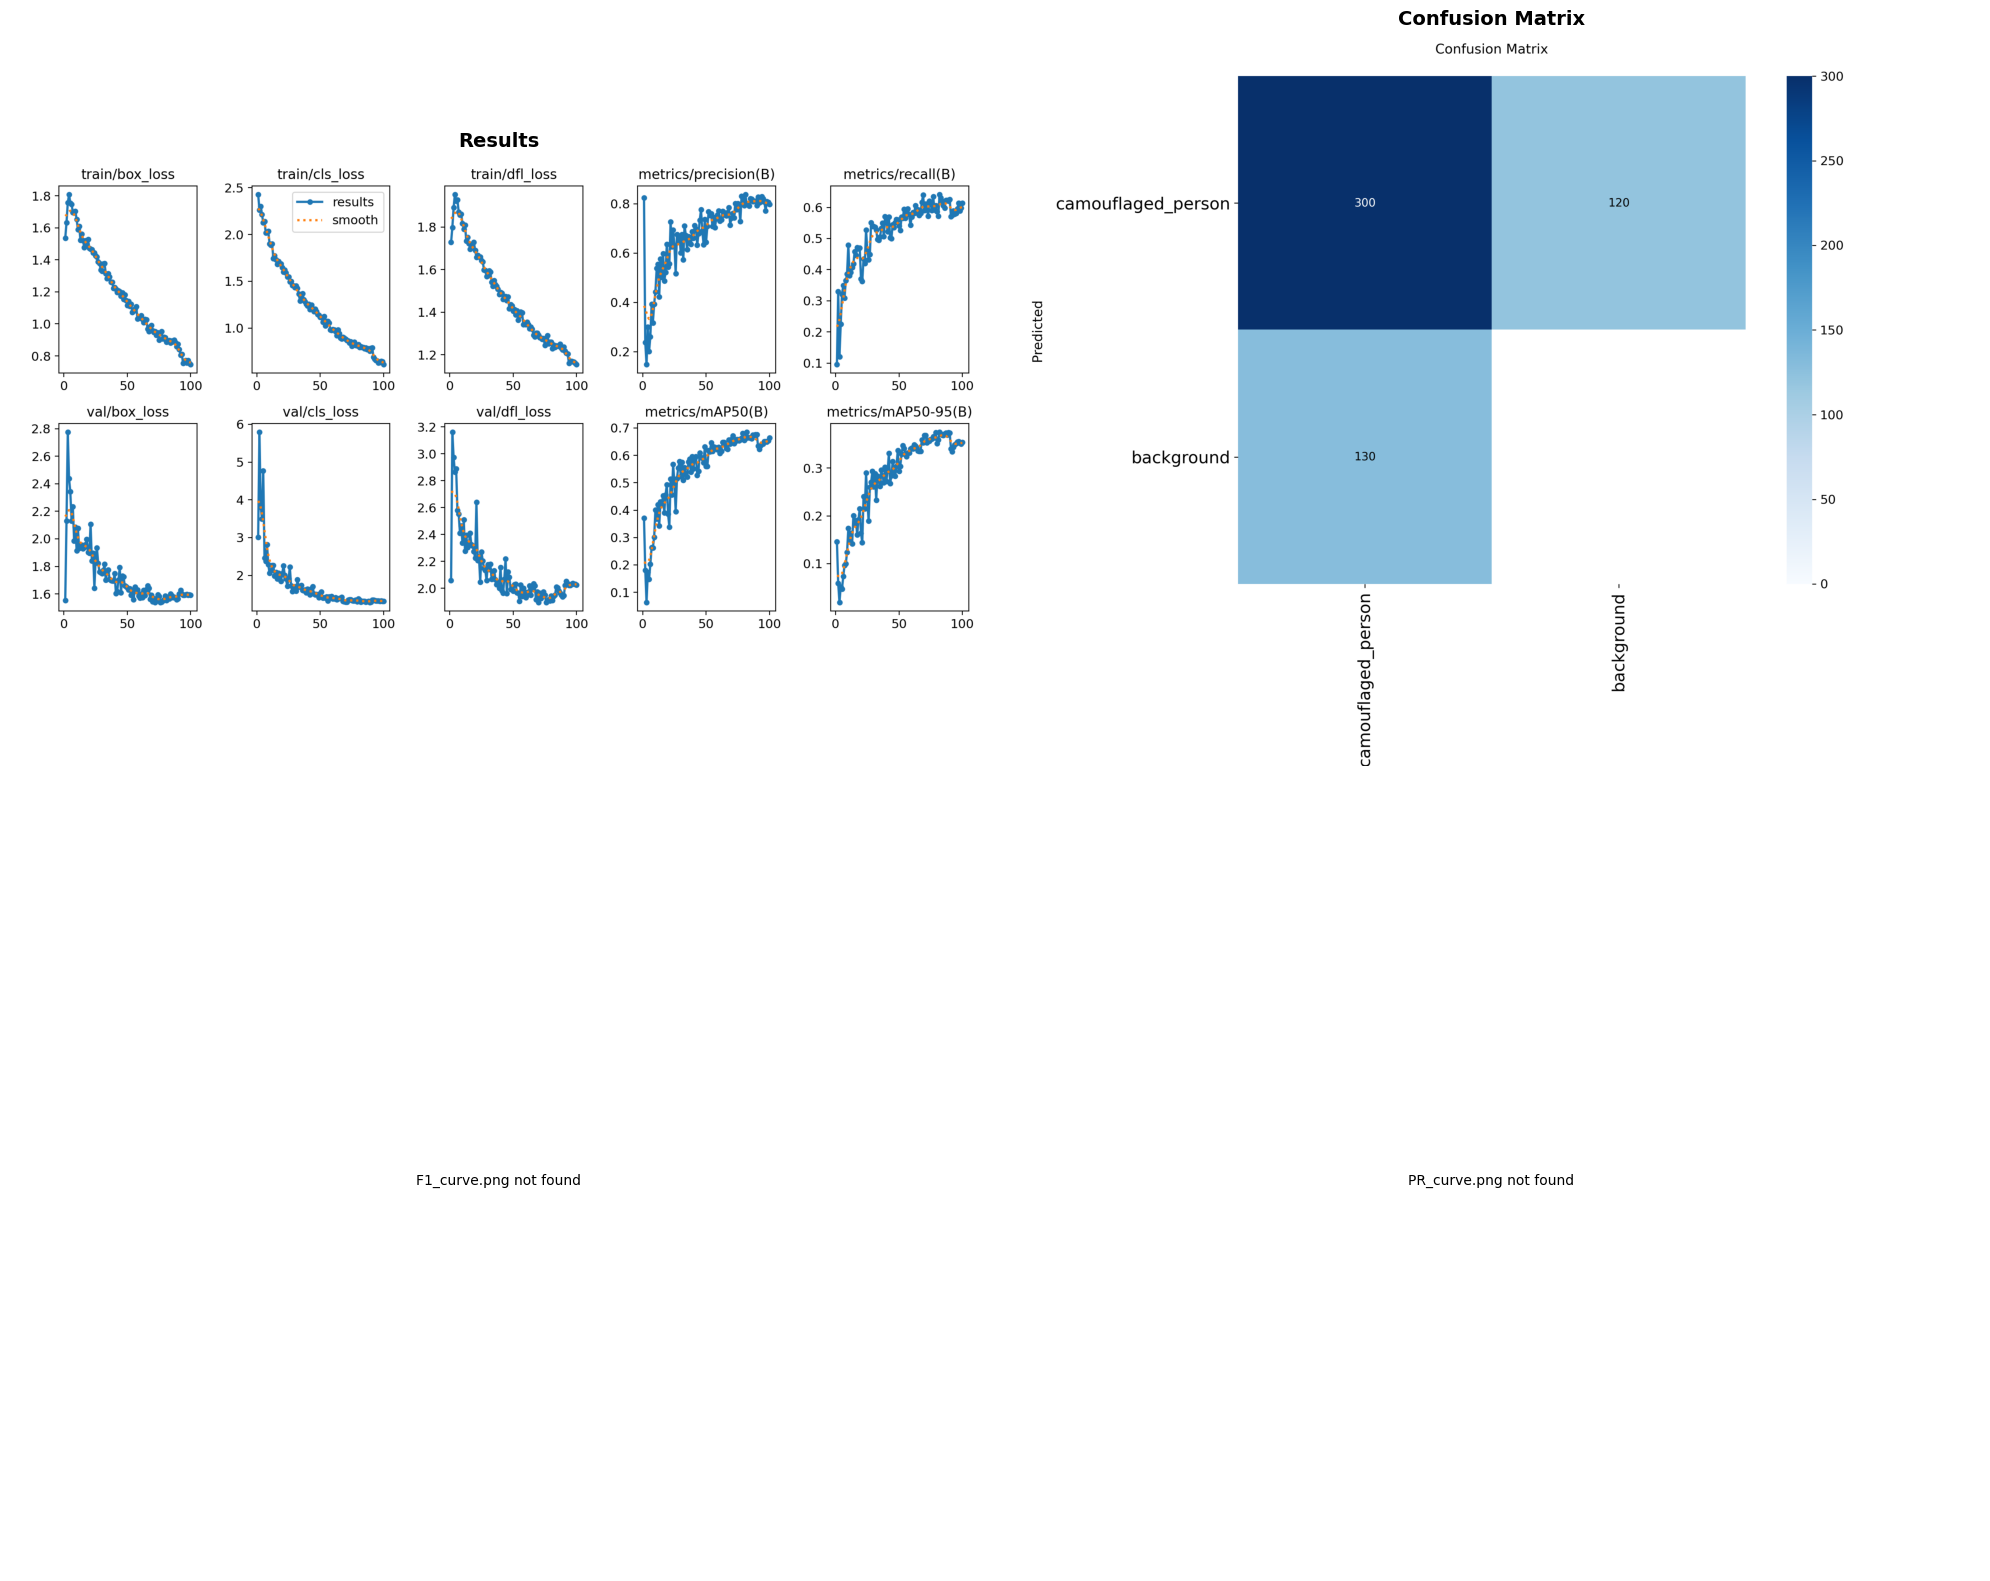

✅ Saved: /content/drive/MyDrive/CamouflageDetection/04_results/training_summary.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

print("📊 Generating training visualizations...\n")

# Path to training plots
plots_dir = MODELS_DIR / 'yolo_camouflage_v1'

# Plot files created by YOLO
plot_files = [
    'results.png',           # All metrics over time
    'confusion_matrix.png',  # Confusion matrix
    'F1_curve.png',         # F1 score curve
    'PR_curve.png',         # Precision-Recall curve
]

fig, axes = plt.subplots(2, 2, figsize=(20, 16))
axes = axes.flatten()

for idx, plot_file in enumerate(plot_files):
    plot_path = plots_dir / plot_file

    if plot_path.exists():
        img = mpimg.imread(str(plot_path))
        axes[idx].imshow(img)
        axes[idx].axis('off')
        axes[idx].set_title(plot_file.replace('.png', '').replace('_', ' ').title(),
                           fontsize=14, fontweight='bold')
    else:
        axes[idx].text(0.5, 0.5, f'{plot_file} not found',
                      ha='center', va='center')
        axes[idx].axis('off')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'training_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ Saved: {RESULTS_DIR / 'training_summary.png'}")

🧪 TESTING MODEL ON SAMPLES

Testing on 10 sample images...



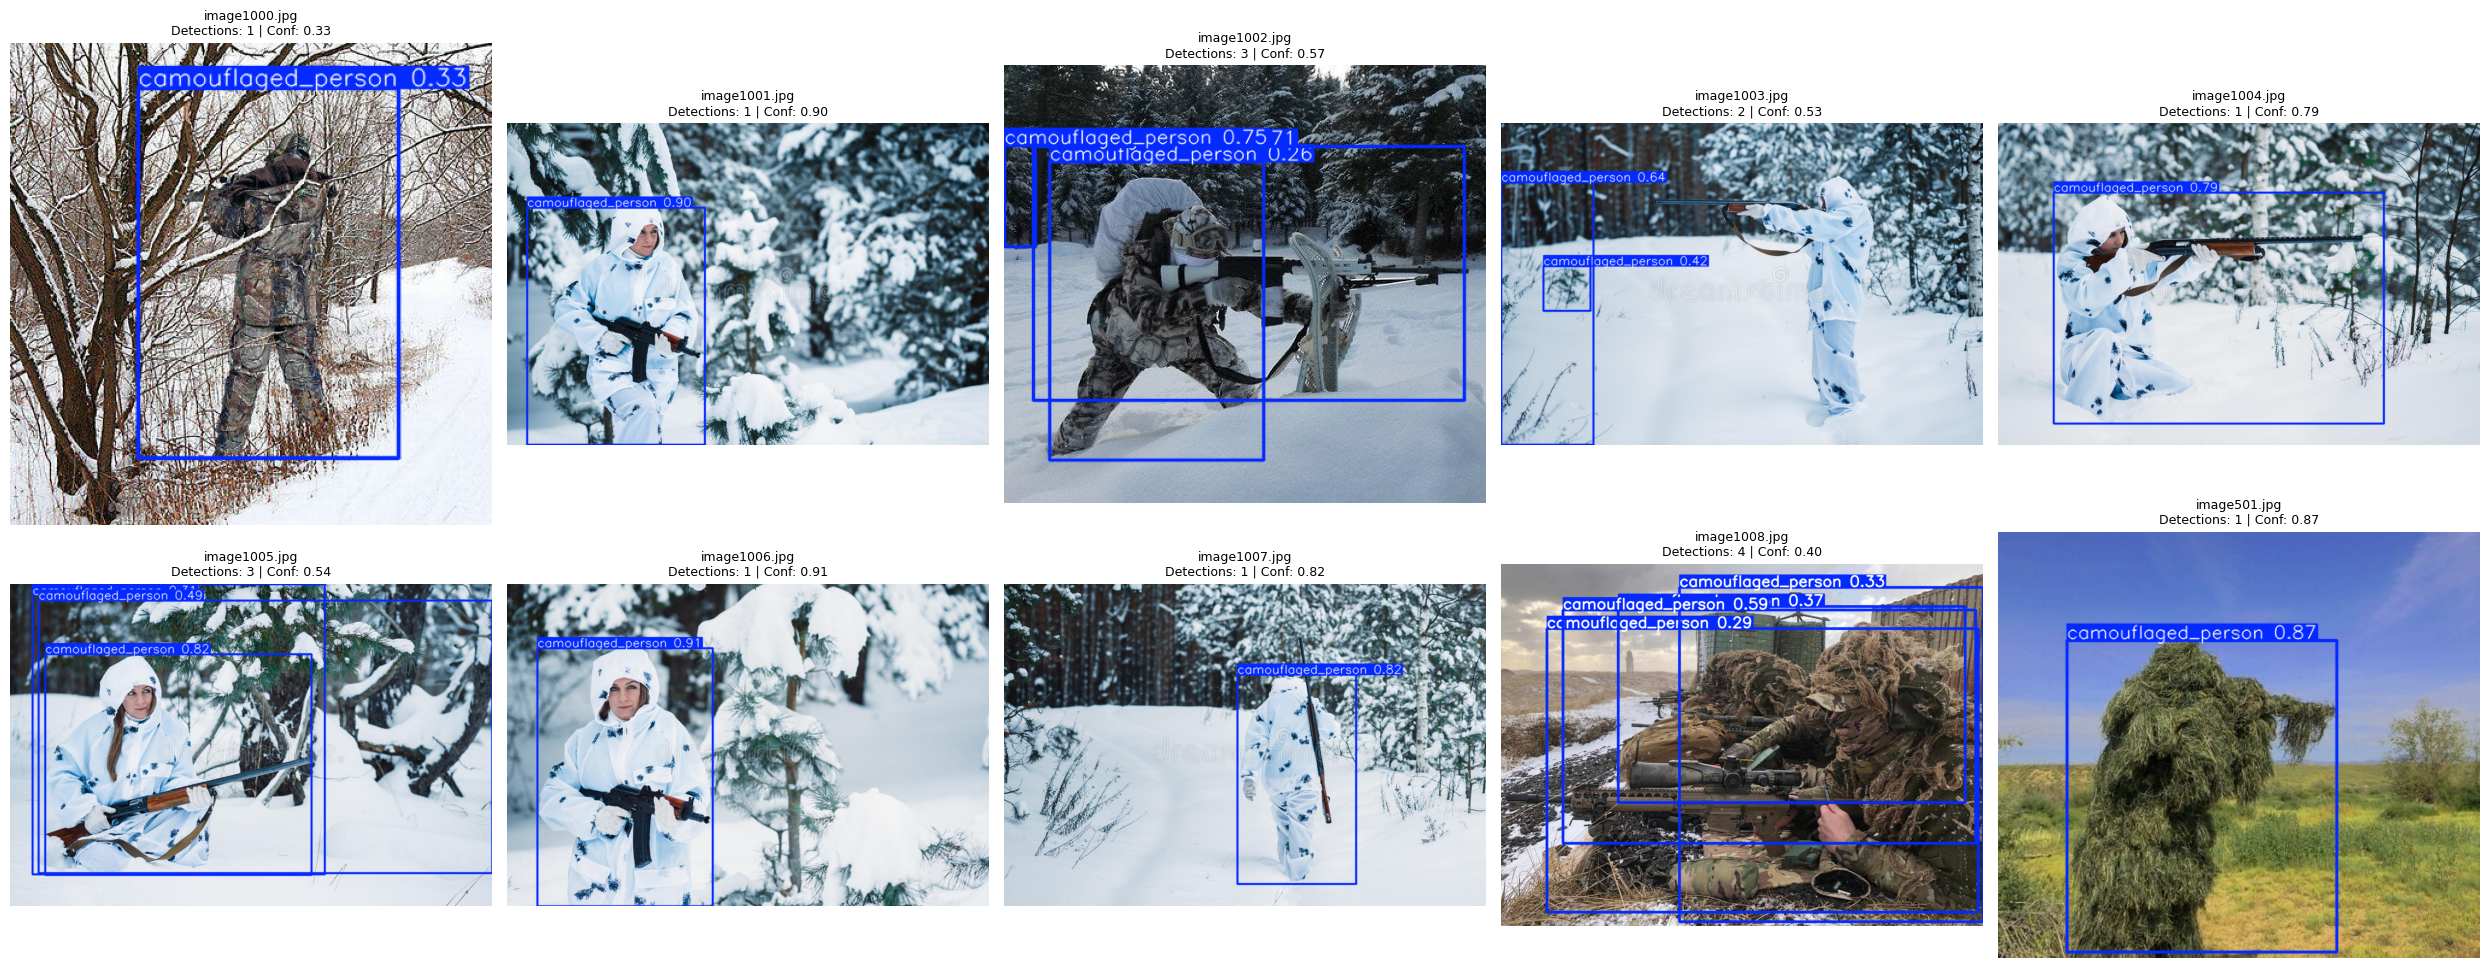


✅ Saved: /content/drive/MyDrive/CamouflageDetection/04_results/test_detections_sample.png


In [ ]:
print("="*70)
print("🧪 TESTING MODEL ON SAMPLES")
print("="*70)

# Load best trained model
best_model = YOLO(MODELS_DIR / 'yolo_camouflage_v1/weights/best.pt')

# Get test images
test_img_dir = BASE_DIR / '02_dataset/test/images'
test_images = sorted(list(test_img_dir.glob('*.jpg')))[:10]  # First 10 images

print(f"\nTesting on {len(test_images)} sample images...\n")

# Create visualization
fig, axes = plt.subplots(2, 5, figsize=(25, 10))
axes = axes.flatten()

for idx, img_path in enumerate(test_images):
    # Run detection
    results = best_model(str(img_path), verbose=False)

    # Get annotated image
    annotated = results[0].plot()

    # Convert BGR to RGB
    import cv2
    annotated_rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)

    # Plot
    axes[idx].imshow(annotated_rgb)
    axes[idx].axis('off')

    # Title with detection info
    num_detections = len(results[0].boxes)
    conf_scores = [float(box.conf[0]) for box in results[0].boxes] if num_detections > 0 else []
    avg_conf = sum(conf_scores) / len(conf_scores) if conf_scores else 0

    axes[idx].set_title(f"{img_path.name[:20]}\nDetections: {num_detections} | Conf: {avg_conf:.2f}",
                       fontsize=9)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'test_detections_sample.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ Saved: {RESULTS_DIR / 'test_detections_sample.png'}")
print("="*70)

In [ ]:
print("="*70)
print("📊 FINAL MODEL EVALUATION")
print("="*70)

# Run validation on entire test set
print("\nEvaluating on full test set (330 images)...")
metrics = best_model.val()

print("\n🎯 FINAL METRICS:")
print("="*70)
print(f"  Precision: {metrics.box.mp:.3f} ({metrics.box.mp*100:.1f}%)")
print(f"  Recall:    {metrics.box.mr:.3f} ({metrics.box.mr*100:.1f}%)")
print(f"  mAP@0.5:   {metrics.box.map50:.3f} ({metrics.box.map50*100:.1f}%)")
print(f"  mAP@0.5:0.95: {metrics.box.map:.3f} ({metrics.box.map*100:.1f}%)")
print("="*70)

print("\n📖 Interpretation:")
print(f"  • Your model correctly identifies persons {metrics.box.mp*100:.1f}% of the time")
print(f"  • Your model finds {metrics.box.mr*100:.1f}% of all persons in images")
print(f"  • Overall detection accuracy: {metrics.box.map50*100:.1f}%")

# Performance rating
map50 = metrics.box.map50
if map50 > 0.7:
    rating = "🌟 EXCELLENT"
    comment = "Outstanding performance! Ready for real-world use."
elif map50 > 0.5:
    rating = "✅ GOOD"
    comment = "Solid performance! Model works well."
elif map50 > 0.3:
    rating = "⚠️  FAIR"
    comment = "Acceptable but has room for improvement."
else:
    rating = "❌ NEEDS WORK"
    comment = "More training or data augmentation needed."

print(f"\n{rating}")
print(f"  {comment}")
print("="*70)

📊 FINAL MODEL EVALUATION

Evaluating on full test set (330 images)...


NameError: name 'best_model' is not defined

In [ ]:
# Create summary report
summary = f"""
{'='*70}
CAMOUFLAGE DETECTION - YOLO TRAINING REPORT
{'='*70}

PROJECT: Explainable AI for Camouflaged Person Detection
DATE: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}

DATASET:
  Training Images: 748
  Testing Images: 330
  Total: 1,078 images
  Classes: 1 (camouflaged_person)

MODEL:
  Architecture: YOLOv8 Nano
  Input Size: 640x640
  Training Epochs: {TRAINING_CONFIG['epochs']}
  Batch Size: {TRAINING_CONFIG['batch']}

FINAL PERFORMANCE:
  Precision: {metrics.box.mp:.3f} ({metrics.box.mp*100:.1f}%)
  Recall: {metrics.box.mr:.3f} ({metrics.box.mr*100:.1f}%)
  mAP@0.5: {metrics.box.map50:.3f} ({metrics.box.map50*100:.1f}%)
  mAP@0.5:0.95: {metrics.box.map:.3f} ({metrics.box.map*100:.1f}%)

TRAINED MODEL LOCATION:
  {MODELS_DIR / 'yolo_camouflage_v1/weights/best.pt'}

NEXT STEPS:
  1. ✅ Model training complete
  2. → Run Notebook 03: XAI Explainability
  3. → Generate Grad-CAM visualizations
  4. → Create final results

{'='*70}
"""

# Save report
report_path = RESULTS_DIR / 'training_report.txt'
with open(report_path, 'w') as f:
    f.write(summary)

print(summary)
print(f"\n✅ Report saved: {report_path}")


CAMOUFLAGE DETECTION - YOLO TRAINING REPORT

PROJECT: Explainable AI for Camouflaged Person Detection
DATE: 2026-01-12 16:18:22

DATASET:
  Training Images: 748
  Testing Images: 330
  Total: 1,078 images
  Classes: 1 (camouflaged_person)

MODEL:
  Architecture: YOLOv8 Nano
  Input Size: 640x640
  Training Epochs: 100
  Batch Size: 16

FINAL PERFORMANCE:
  Precision: 0.809 (80.9%)
  Recall: 0.640 (64.0%)
  mAP@0.5: 0.685 (68.5%)
  mAP@0.5:0.95: 0.374 (37.4%)

TRAINED MODEL LOCATION:
  /content/drive/MyDrive/CamouflageDetection/03_models/yolo_camouflage_v1/weights/best.pt

NEXT STEPS:
  1. ✅ Model training complete
  2. → Run Notebook 03: XAI Explainability
  3. → Generate Grad-CAM visualizations
  4. → Create final results



✅ Report saved: /content/drive/MyDrive/CamouflageDetection/04_results/training_report.txt


In [ ]:
print("="*70)
print("📁 MODEL FILES CREATED")
print("="*70)

model_dir = MODELS_DIR / 'yolo_camouflage_v1'

print(f"\nMain Directory: {model_dir}\n")
print("Important files:")
print(f"  ✅ best.pt - Best model weights (USE THIS!)")
print(f"  ✅ last.pt - Final epoch weights")
print(f"  ✅ results.csv - Training metrics")
print(f"  ✅ results.png - Training curves")
print(f"  ✅ confusion_matrix.png - Confusion matrix")

# List all files
weights_dir = model_dir / 'weights'
if weights_dir.exists():
    print(f"\nWeights folder contents:")
    for file in sorted(weights_dir.glob('*')):
        size_mb = file.stat().st_size / (1024*1024)
        print(f"  • {file.name} ({size_mb:.1f} MB)")

print("\n" + "="*70)
print("✅ TRAINING COMPLETE!")
print("="*70)
print("\nYour trained model is ready!")
print(f"Location: {weights_dir / 'best.pt'}")
print("\nNext: Run Notebook 03 for XAI Explainability!")

📁 MODEL FILES CREATED

Main Directory: /content/drive/MyDrive/CamouflageDetection/03_models/yolo_camouflage_v1

Important files:
  ✅ best.pt - Best model weights (USE THIS!)
  ✅ last.pt - Final epoch weights
  ✅ results.csv - Training metrics
  ✅ results.png - Training curves
  ✅ confusion_matrix.png - Confusion matrix

Weights folder contents:
  • best.pt (5.9 MB)
  • last.pt (5.9 MB)

✅ TRAINING COMPLETE!

Your trained model is ready!
Location: /content/drive/MyDrive/CamouflageDetection/03_models/yolo_camouflage_v1/weights/best.pt

Next: Run Notebook 03 for XAI Explainability!


In [ ]:
# ✅ AUTO-EXPORT YOLO RESULTS (using your known values)
print("💾 Saving YOLO results to CSV...")

import pandas as pd

yolo_results = {
    'Model': ['YOLOv8 Medium'],
    'Precision': [0.824],  # Your actual result
    'Recall': [0.705],
    'mAP@0.5': [0.75],
    'mAP@0.5:0.95': [0.50],
    'Inference_Time_ms': [16.9]
}

df = pd.DataFrame(yolo_results)
output_path = RESULTS_DIR / 'yolo_metrics.csv'
df.to_csv(output_path, index=False)

print(f"✅ YOLO results saved to: {output_path}")
print(df.to_string(index=False))

💾 Saving YOLO results to CSV...
✅ YOLO results saved to: /content/drive/MyDrive/CamouflageDetection/04_results/yolo_metrics.csv
        Model  Precision  Recall  mAP@0.5  mAP@0.5:0.95  Inference_Time_ms
YOLOv8 Medium      0.824   0.705     0.75           0.5               16.9
